In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import required libraries
from google.cloud import bigquery

# Initialize the BigQuery client
client = bigquery.Client(project="customer-chrun-project")

# Define the SQL query to pull your feature engineering matrix
query = """
    SELECT * FROM `customer-chrun-project.ravenstack_analytics.churn_feature_matrix`
"""

# Execute the query and load the results directly into a Pandas DataFrame
df = client.query(query).to_dataframe()

# Display the first 5 rows and the shape of the dataset to verify
print(f"Dataset Shape: {df.shape}")
display(df.head())

c:\Users\SAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\SAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset Shape: (500, 15)


,account_id,industry,plan_tier,referral_source,subscription_id,total_usage_events,last_usage_date,days_since_last_usage,total_tickets,avg_satisfaction_score,mrr,days_to_renewal,renewal_urgency,churn_target,churn_label
0,A-1b707d,Cybersecurity,Enterprise,organic,S-47985c,2,2024-11-01,60,3,0.00,0,361,Not Urgent,1,At-Risk
1,A-fd7ad3,Cybersecurity,Enterprise,event,S-4f43fd,6,2024-11-20,41,8,4.17,551,26,Renewing in 30 Days,1,At-Risk
2,A-443b7c,Cybersecurity,Enterprise,other,S-1e83a6,3,2024-12-27,4,8,4.40,152,363,Not Urgent,0,Retained
3,A-89ee83,Cybersecurity,Pro,organic,S-bf304b,3,2024-05-17,228,5,4.00,3582,27,Renewing in 30 Days,0,Retained
4,A-e19ff6,Cybersecurity,Enterprise,partner,S-d90f0a,2,2023-08-03,516,3,4.67,1274,23,Renewing in 30 Days,1,At-Risk


In [3]:
# 1. Check for missing values (Validating our SQL COALESCE logic)
print("--- Missing Values Check ---")
display(df.isnull().sum())

# 2. Check Class Imbalance
print("\n--- Churn Class Distribution ---")
churn_distribution = df['churn_target'].value_counts(normalize=True) * 100
display(churn_distribution.round(2).astype(str) + '%')

--- Missing Values Check ---


account_id                0
industry                  0
plan_tier                 0
referral_source           0
subscription_id           0
total_usage_events        4
last_usage_date           4
days_since_last_usage     0
total_tickets             8
avg_satisfaction_score    8
mrr                       0
days_to_renewal           0
renewal_urgency           0
churn_target              0
churn_label               0
dtype: int64


--- Churn Class Distribution ---


churn_target
1    70.4%
0    29.6%
Name: proportion, dtype: object

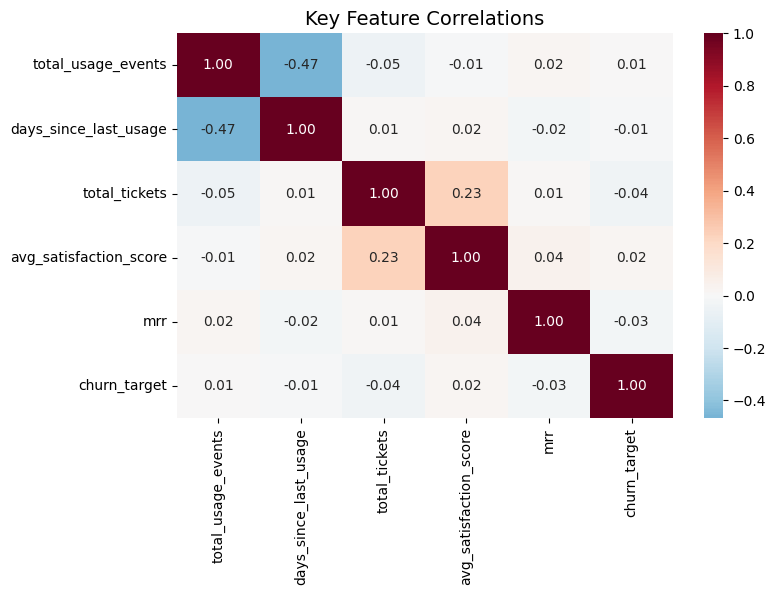

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Generate a CLEAN Correlation Matrix
# Only include actual features and the target
features_to_check = ['total_usage_events', 'days_since_last_usage', 'total_tickets', 'avg_satisfaction_score', 'mrr', 'churn_target']
corr_matrix = df[features_to_check].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Key Feature Correlations", fontsize=14)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("--- Starting Preprocessing ---")

# Date Feature Engineering
df['last_usage_date'] = pd.to_datetime(df['last_usage_date'])
df['last_usage_year'] = df['last_usage_date'].dt.year
df['last_usage_month'] = df['last_usage_date'].dt.month
df['last_usage_day'] = df['last_usage_date'].dt.day
df['last_usage_weekday'] = df['last_usage_date'].dt.weekday

# Define Features (X) and Target (y)
# churn_label and renewal_urgency are derived labels — excluded from features
# days_to_renewal stays in X as a predictive feature
X = df.drop(columns=[
    'account_id',
    'subscription_id',
    'churn_target',
    'churn_label',          # string version of the target — drop
    'renewal_urgency',      # derived label — drop
    'last_usage_date'       # replaced by decomposed date features above
])
y = df['churn_target']

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"\nFeatures used: {list(X.columns)}")

--- Starting Preprocessing ---
Training Features Shape: (400, 20)
Testing Features Shape:  (100, 20)

Features used: ['total_usage_events', 'days_since_last_usage', 'total_tickets', 'avg_satisfaction_score', 'mrr', 'days_to_renewal', 'last_usage_year', 'last_usage_month', 'last_usage_day', 'last_usage_weekday', 'industry_DevTools', 'industry_EdTech', 'industry_FinTech', 'industry_HealthTech', 'plan_tier_Enterprise', 'plan_tier_Pro', 'referral_source_event', 'referral_source_organic', 'referral_source_other', 'referral_source_partner']


In [6]:
from xgboost import XGBClassifier

print("--- Training XGBoost Model ---")

# 1. Handle Class Imbalance mathematically
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

# Calculate the optimal weight for the minority class
scale_weight = negative_class / positive_class
print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

# 2. Initialize the XGBoost Model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_weight,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

# 3. Train the Model
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

--- Training XGBoost Model ---
Calculated scale_pos_weight: 0.42
XGBoost model training complete.


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Model Evaluation ---")

# Generate predictions on the unseen test data
y_pred = xgb_model.predict(X_test)

# Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Evaluation ---
Confusion Matrix:
[[ 9 21]
 [22 48]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.29      0.30      0.30        30
         1.0       0.70      0.69      0.69        70

    accuracy                           0.57       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.57      0.57      0.57       100



--- Explainable AI (SHAP) ---


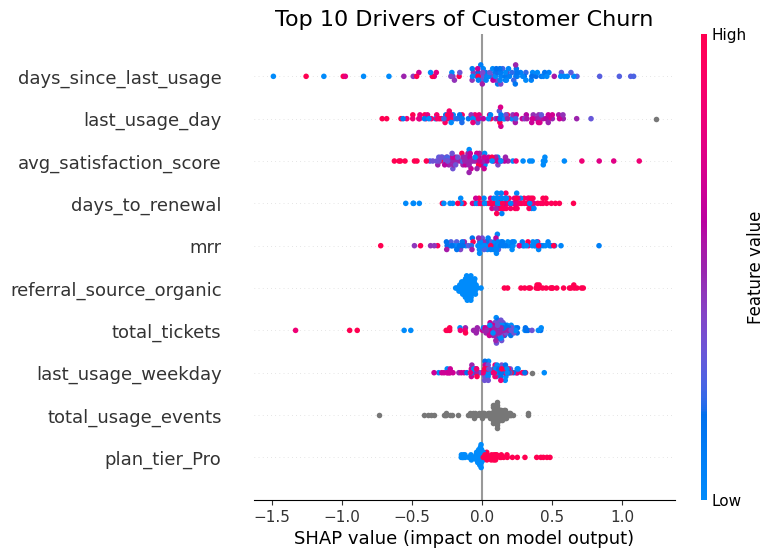


Generating Local Explanation for Test Customer Index: 0


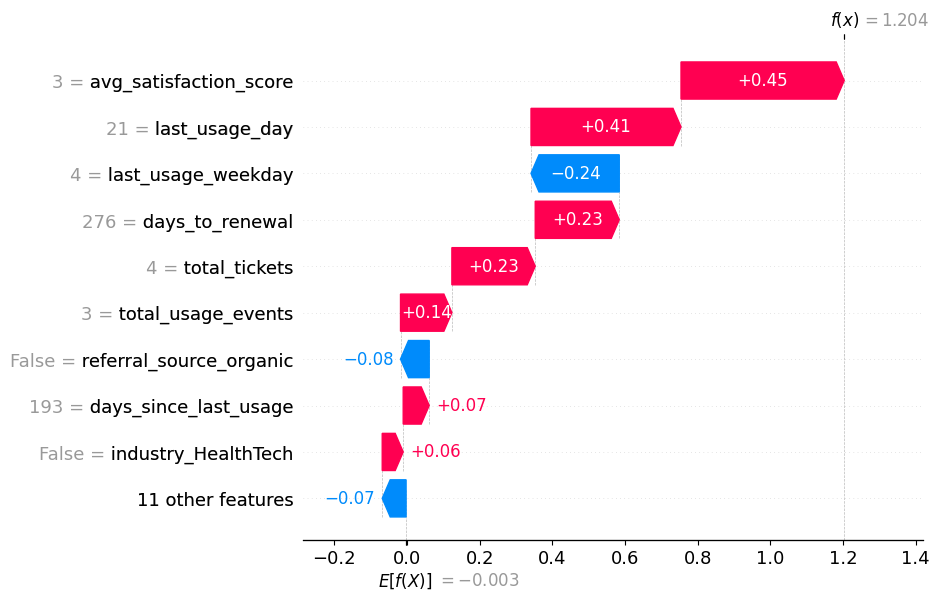

In [8]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("--- Explainable AI (SHAP) ---")

# 1. Initialize the SHAP explainer for our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values for the test dataset
shap_values = explainer(X_test)

# Generate predictions
y_pred = xgb_model.predict(X_test)

# GLOBAL EXPLANATION: Summary Plot
plt.figure(figsize=(10, 6))
# max_display=10 keeps the visual focused on the top drivers only
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("Top 10 Drivers of Customer Churn", fontsize=16)
plt.show()

# 4. LOCAL EXPLANATION: Waterfall Plot
# Find the indices of customers the model predicted as churners
churn_indices = np.where(y_pred == 1)[0]  # [0] to get the array

if len(churn_indices) > 0:
    # Pick the first churner for local explanation
    first_churner_idx = churn_indices[0]  # single integer index

    print(f"\nGenerating Local Explanation for Test Customer Index: {first_churner_idx}")
    plt.figure(figsize=(10, 6))
    
    # Pass exactly one row to the waterfall plot
    shap.plots.waterfall(shap_values[first_churner_idx], max_display=10)
else:
    print("No churners predicted in the test set to explain.")

In [9]:
import shap
import pandas as pd

print("--- Exporting SHAP Values to BigQuery (Long Format) ---")

# ── 1. Build X_export matching the training feature set exactly
X_full = df.drop(columns=[
    'account_id',
    'subscription_id',
    'churn_target',
    'churn_label',       
    'renewal_urgency',   
    'last_usage_date'
])
X_full = pd.get_dummies(X_full, drop_first=True)
X_export = X_full[X_train.columns].copy()
X_export.index = df['account_id']

# ── 2. Compute SHAP for ALL accounts
explainer = shap.TreeExplainer(xgb_model)
shap_values_all = explainer(X_export)

# ── 3. Wide DataFrame
shap_wide = pd.DataFrame(
    shap_values_all.values,
    columns=X_export.columns,
    index=X_export.index
).reset_index().rename(columns={'index': 'account_id'})

# ── 4. Melt to LONG format
shap_long = shap_wide.melt(
    id_vars='account_id',
    var_name='feature_name',
    value_name='shap_value'
)

# ── 5. Readable display names (days_to_renewal added)
def make_display_name(f):
    name_map = {
        'total_usage_events':    'Total Usage Events',
        'days_since_last_usage': 'Days Since Last Usage',
        'days_to_renewal':       'Days to Renewal',       
        'total_tickets':         'Total Support Tickets',
        'avg_satisfaction_score':'Avg Satisfaction Score',
        'mrr':                   'Monthly Revenue (MRR)',
        'last_usage_year':       'Last Usage Year',
        'last_usage_month':      'Last Usage Month',
        'last_usage_day':        'Last Usage Day',
        'last_usage_weekday':    'Last Usage Weekday',
    }
    if f in name_map:
        return name_map[f]
    if f.startswith('industry_'):
        return f"Industry: {f.replace('industry_', '')}"
    if f.startswith('plan_tier_'):
        return f"Plan: {f.replace('plan_tier_', '')}"
    if f.startswith('referral_source_'):
        return f"Source: {f.replace('referral_source_', '')}"
    return f

shap_long['feature_display_name'] = shap_long['feature_name'].apply(make_display_name)

# ── 6. Keep TOP 7 features per account
shap_long['abs_shap'] = shap_long['shap_value'].abs()
shap_top7 = (
    shap_long
    .sort_values('abs_shap', ascending=False)
    .groupby('account_id')
    .head(7)
    .drop(columns='abs_shap')
    .reset_index(drop=True)
)

# ── 7. Push to BigQuery
import pandas_gbq
pandas_gbq.to_gbq(
    shap_top7,
    destination_table='ravenstack_analytics.shap_explanations',
    project_id='customer-chrun-project',
    if_exists='replace'
)
print(f"Exported {len(shap_top7)} rows ({len(df)} accounts x up to 7 features)")

--- Exporting SHAP Values to BigQuery (Long Format) ---


c:\Users\SAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
100%|██████████| 1/1 [00:00<00:00, 2861.05it/s]

Exported 3500 rows (500 accounts x up to 7 features)


In [10]:
print("--- Exporting Churn Probabilities to BigQuery ---")

# Predict probability for all 500 accounts
churn_proba = xgb_model.predict_proba(X_export)[:, 1]

prob_df = pd.DataFrame({
    'account_id': df['account_id'].values,
    'churn_probability': churn_proba.round(4)
})

pandas_gbq.to_gbq(
    prob_df,
    destination_table='ravenstack_analytics.churn_scores',
    project_id='customer-chrun-project',
    if_exists='replace'
)
print(f"Exported churn probability scores for {len(prob_df)} accounts")

--- Exporting Churn Probabilities to BigQuery ---


100%|██████████| 1/1 [00:00<00:00, 1984.06it/s]

Exported churn probability scores for 500 accounts
